# Oracle Machine Learning for R (OML4R)

***Oracle Machine Learning for R*** (OML4R) makes the open source R programming language and environment ready for the enterprise and big data. 
Designed for problems involving both large and small data volumes, OML4R integrates R with Oracle Autonomous Database, allowing users to run R 
commands for statistical, machine learning, and visualization analyses on database tables and views using R syntax. Many familiar R functions 
are overloaded that translate R behavior for running in-database, as well as new automatic machine learning capabilities. 

In this notebook, we highlight a few of the OML4R features:
* Load ORE Library
* Create database tables
* Use the transparency layer
* Rank attributes for predicitve value using the in-database attribute importance algorithm
* Build predicitve models
* Score data using these models

Copyright (c) 2025 Oracle Corporation

###### <a href="https://oss.oracle.com/licenses/upl/" onclick="return ! window.open('https://oss.oracle.com/licenses/upl/');">The Universal Permissive License (UPL), Version 1.0</a>

## Import libraries supporting OML4R

To use OML4R, first import the library **ORE**.

Users can get online help using R's help function and specifying the function of interest.

In [1]:
library(ORE)
library(lattice)

options(ore.warn.order=FALSE)

In [2]:
# z.show(head(iris, 10))
ore.pull(head(iris, 10))

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa
7,4.6,3.4,1.4,0.3,setosa
8,5.0,3.4,1.5,0.2,setosa
9,4.4,2.9,1.4,0.2,setosa


## OML4R Transparency Layer functionality
### Using an R data.frame, create a database table and obtain a proxy object
We have a couple of options for loading data into the database from R. In this first example, we load the **iris** dataset This R data.frame can then be loaded into the database using the ***push*** function, which creates a temporary table and returns a proxy object that we assign to variable IRIS_TMP. Such temporary tables will be automatically deleted when the database connection is terminated unless the proxy object is saved in a datastore (the topics of 'datastore' is covered in another notebook).

We then invoke standard functions like ***shape*** and ***columns***, as well as ***head***, to begin to explore the data.

In [3]:
help(ore.push)

ore.pull {OREbase},R Documentation
x,"For function ore.pull, ore objects. For function ore.push, vector, data.frame, matrix, or list objects."
...,For future expansion.


In [4]:
IRIS_TMP <- ore.push(iris)

dim(IRIS_TMP)
colnames(IRIS_TMP)
# z.show(head(IRIS_TMP,10))
ore.pull(head(IRIS_TMP, 10))

[1] 150   5

[1] "Sepal.Length" "Sepal.Width"  "Petal.Length" "Petal.Width"  "Species"

Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
<dbl>,<dbl>,<dbl>,<dbl>,<fct>
5.1,3.5,1.4,0.2,setosa
4.9,3.0,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5.0,3.6,1.4,0.2,setosa
5.4,3.9,1.7,0.4,setosa
4.6,3.4,1.4,0.3,setosa
5.0,3.4,1.5,0.2,setosa
4.4,2.9,1.4,0.2,setosa


We can also create a persistent table using the ***create*** function and specify an R data.frame and a tablename. 
For emample, here we sepecify **IRIS2**. This table is now accessible both within OML4R and directly from SQL.
Use the function ***z.show*** to automatically pull the desired data to R  for display in the notebook. 
By doing this, you can also use the built-in notebook visualization options such as a bar, pie, area, line, and scatter plots.

In [5]:
ore.attach()

tryCatch(ore.drop(table="IRIS2"))

ore.create(iris, table="IRIS2")

# z.show(head(IRIS2, 10))
ore.pull(head(IRIS2, 10))

Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
<dbl>,<dbl>,<dbl>,<dbl>,<fct>
5.1,3.5,1.4,0.2,setosa
4.9,3.0,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5.0,3.6,1.4,0.2,setosa
5.4,3.9,1.7,0.4,setosa
4.6,3.4,1.4,0.3,setosa
5.0,3.4,1.5,0.2,setosa
4.4,2.9,1.4,0.2,setosa


### Transparency layer functions available on an ORE data.frame, or `ore.frame`.
List the functions defined for an ORE DataFrame proxy object, in this case "IRIS."

In [6]:
class(IRIS_TMP)

[1] "ore.frame"
attr(,"package")
[1] "OREbase"

In [7]:
class <- methods(class=class(IRIS_TMP))
class

  [1] !                [                [[               [[<-            
  [5] [<-              %*%              $                $<-             
  [9] Arith            as.character     as.data.frame    as.env          
 [13] as.integer       as.list          as.logical       as.matrix       
 [17] as.numeric       as.ore           as.ore.character as.ore.factor   
 [21] as.ore.frame     as.ore.integer   as.ore.list      as.ore.logical  
 [25] as.ore.matrix    as.ore.numeric   as.vector        attach          
 [29] by               cbind            coerce           colMeans        
 [33] colnames         colnames<-       colSums          Compare         
 [37] complete.cases   coplot           cor              cov             
 [41] crossprod        data.frame       dbWriteTable     decode          
 [45] dim              dimnames         dimnames<-       encode          
 [49] eval             get_all_vars     head             initialize      
 [53] interaction      is.finite      

### Using standard R syntax on database data
Perform a few operations on the SEPAL_LENGTH column of the IRIS database table using the transparency layer. Note that standard R syntax is used

In [8]:
cat("Add 5 to each SEPAL_LENGTH: \n")
IRIS_TMP[1:20,1]+5

cat("\n\nMin SEPAL_LENGTH:  ", min(IRIS_TMP[,1]))
cat("\n\nMin SEPAL_LENGTH:  ", min(IRIS_TMP$Sepal.Length))

cat("\n\nMean SEPAL_LENGTH:  ", mean(IRIS_TMP[,1]))
cat("\n\nMean SEPAL_LENGTH:  ", mean(IRIS_TMP$Sepal.Length))

Add 5 to each SEPAL_LENGTH: 


 [1] 10.1  9.9  9.7  9.6 10.0 10.4  9.6 10.0  9.4  9.9 10.4  9.8  9.8  9.3 10.8
[16] 10.7 10.4 10.1 10.7 10.1



Min SEPAL_LENGTH:   4.3

Min SEPAL_LENGTH:   4.3

Mean SEPAL_LENGTH:   5.843333

Mean SEPAL_LENGTH:   5.843333

Explore masking using the IRIS Petal.Length column. Note that standard R syntax is used.

In [9]:
base <- IRIS_TMP$Petal.Length

MASK1 <- IRIS_TMP[,3] > 5.1
mask1 <- IRIS_TMP$Petal.Length[MASK1]

MASK2 <- IRIS_TMP[,3] < 1.4 | IRIS_TMP[,3] > 5.6
mask2 <- IRIS_TMP$Petal.Length[MASK2]

In [10]:
cat("Petal Length:\n")
base

cat("\n\nPetal Length > 5.1:\n")
mask1

cat("\n\nPetal Length  < 1.4 | > 5.6:\n")
mask2

Petal Length:


  [1] 1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 1.5 1.6 1.4 1.1 1.2 1.5 1.3 1.4
 [19] 1.7 1.5 1.7 1.5 1.0 1.7 1.9 1.6 1.6 1.5 1.4 1.6 1.6 1.5 1.5 1.4 1.5 1.2
 [37] 1.3 1.4 1.3 1.5 1.3 1.3 1.3 1.6 1.9 1.4 1.6 1.4 1.5 1.4 4.7 4.5 4.9 4.0
 [55] 4.6 4.5 4.7 3.3 4.6 3.9 3.5 4.2 4.0 4.7 3.6 4.4 4.5 4.1 4.5 3.9 4.8 4.0
 [73] 4.9 4.7 4.3 4.4 4.8 5.0 4.5 3.5 3.8 3.7 3.9 5.1 4.5 4.5 4.7 4.4 4.1 4.0
 [91] 4.4 4.6 4.0 3.3 4.2 4.2 4.2 4.3 3.0 4.1 6.0 5.1 5.9 5.6 5.8 6.6 4.5 6.3
[109] 5.8 6.1 5.1 5.3 5.5 5.0 5.1 5.3 5.5 6.7 6.9 5.0 5.7 4.9 6.7 4.9 5.7 6.0
[127] 4.8 4.9 5.6 5.8 6.1 6.4 5.6 5.1 5.6 6.1 5.6 5.5 4.8 5.4 5.6 5.1 5.1 5.9
[145] 5.7 5.2 5.0 5.2 5.4 5.1



Petal Length > 5.1:


 [1] 6.0 5.9 5.6 5.8 6.6 6.3 5.8 6.1 5.3 5.5 5.3 5.5 6.7 6.9 5.7 6.7 5.7 6.0 5.6
[20] 5.8 6.1 6.4 5.6 5.6 6.1 5.6 5.5 5.4 5.6 5.9 5.7 5.2 5.2 5.4



Petal Length  < 1.4 | > 5.6:


 [1] 1.3 1.1 1.2 1.3 1.0 1.2 1.3 1.3 1.3 1.3 1.3 6.0 5.9 5.8 6.6 6.3 5.8 6.1 6.7
[20] 6.9 5.7 6.7 5.7 6.0 5.8 6.1 6.4 6.1 5.9 5.7

### Explore data by computing pairwise correlation
Using only numeric columns, compute a correlation matrix using the **IRIS_TMP** proxy object for the temporary database table using the overloaded **cor** function. Here we see that petal length and petal width are highly correlated.

In [11]:
IRIS_NUMERIC <- IRIS_TMP[, c("Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width")]
class(IRIS_NUMERIC)

RES <- as.data.frame(cor(IRIS_NUMERIC, use = "all.obs"))
class(RES)

RES

[1] "ore.frame"
attr(,"package")
[1] "OREbase"

[1] "data.frame"

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
,<dbl>,<dbl>,<dbl>,<dbl>
Sepal.Length,1.0000000,-0.1175698,0.8717538,0.8179411
Sepal.Width,-0.1175698,1.0000000,-0.4284401,-0.3661259
Petal.Length,0.8717538,-0.4284401,1.0000000,0.9628654
Petal.Width,0.8179411,-0.3661259,0.9628654,1.0000000


### Explore column distributions

OML4R overloads select graphics functions as well. Here, we illustrate the use of ***hist*** and ***boxplot*** to show the distribution of petal length. Here, the statistical computations take place in the database - avoiding data movement - and return only the summary statistics needed to produce the plot, which enables scalability. No overhead is incurred for moving the data to the client for processing, whether 150 rows (as in IRIS) or 150 million rows.

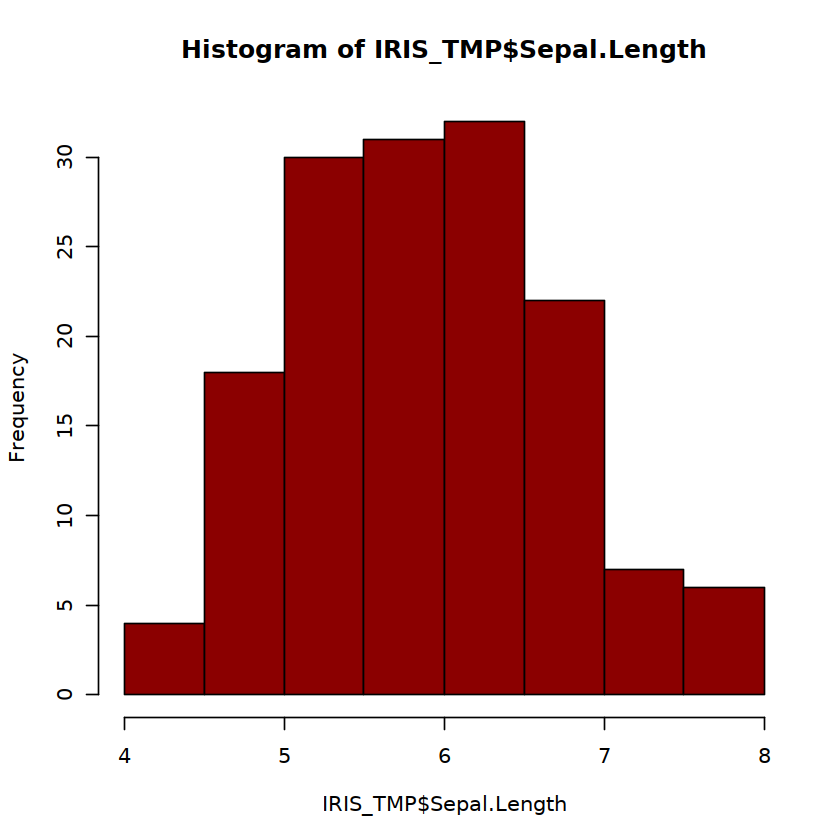

In [12]:
hist(IRIS_TMP$Sepal.Length, col="darkred")

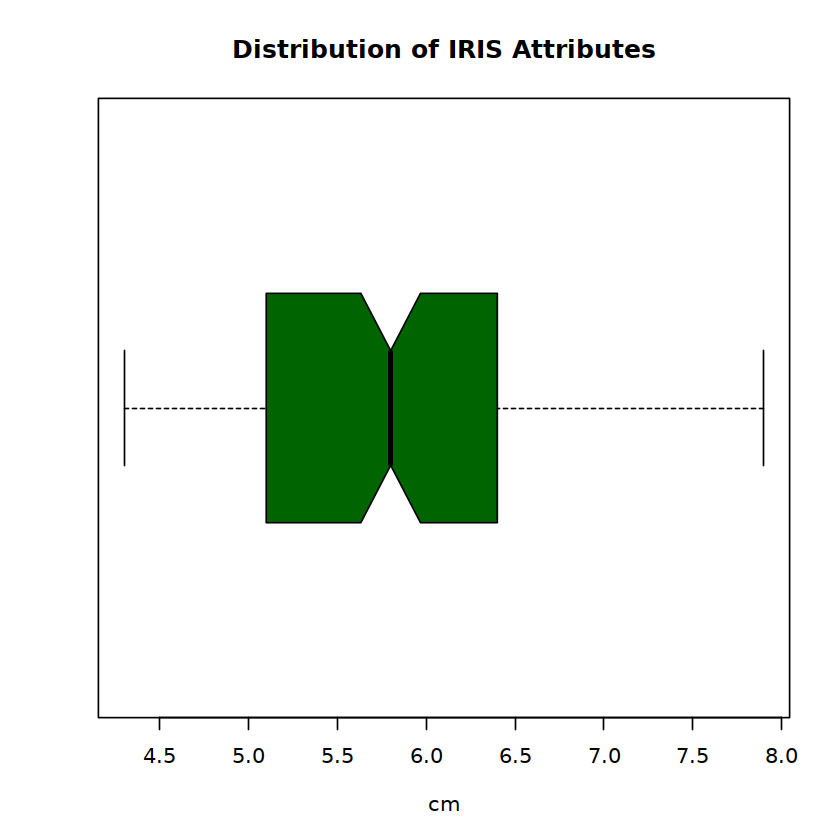

In [13]:
boxplot(IRIS_TMP$Sepal.Length, horizontal=TRUE, notch=TRUE, col="darkgreen", 
        showmeans=TRUE, xlab="cm", main="Distribution of IRIS Attributes")

## Use in-database ML algorithms
### Compute attribute importance variable ranking

Using the **IRIS** table, determine which variables (a.k.a., attributes or predictors) are most important in predicting target Species.

Notice that petal width is most predictive of the target Species. The importance value produced by this algorithm provides a relative ranking, not an absolute number, to be used to distinguish importance among variables.

In [14]:
help(ore.odmAI)

ore.odmAI {OREdm},R Documentation
formula,An object of class formula (or one that can be coerced to that class): a symbolic description of the model to be fitted. The details of model specification are given under 'Details'.
data,An ore.frame object used for computing relative importance.
auto.data.prep,A logical value that specifies whether Oracle Data Mining should invoke automatic data preparation for the build.
na.action,"A function to use for handling missing values, either na.pass to allow missing values or na.omit to remove rows with missing values. The default value is na.pass."
odm.settings,Same as odm.settings in ore.odmKMeans.
importance,A data.frame of terms (predictor variables) as row names with their corresponding importance value and rank.
formula,The formula provided when computing the relative importance.
call,The matched call.


In [15]:
AI <- ore.odmAI(Species ~ ., IRIS_TMP, auto.data.prep = TRUE)
AI


Call:
ore.odmAI(formula = Species ~ ., data = IRIS_TMP, auto.data.prep = TRUE)

Importance: 
             importance rank
Petal.Width   1.0509353    1
Petal.Length  1.0306334    2
Sepal.Length  0.4548240    3
Sepal.Width   0.1915138    4


In [16]:
res <- AI$importance
res$attributes <- rownames(res)

# z.show(res)
ore.pull(res)

,importance,rank,attributes
,<dbl>,<dbl>,<chr>
Petal.Width,1.0509353,1,Petal.Width
Petal.Length,1.0306334,2,Petal.Length
Sepal.Length,0.4548240,3,Sepal.Length
Sepal.Width,0.1915138,4,Sepal.Width


### Build predictive models
In this example, we set up the data and a ***demo*** cost matrix to build a Decision Tree model to predict Species from the **IRIS** table.
Rebuild the model and supply a test cost matrix.

In [17]:
help(ore.odmDT)

ore.odmDT {OREdm},R Documentation
formula,An object of class formula (or one that can be coerced to that class): a symbolic description of the model to be fitted. The details of model specification are given under 'Details'.
data,An ore.frame object used for model building.
auto.data.prep,A logical value that specifies whether Oracle Data Mining should invoke automatic data preparation for the build.
cost.matrix,"An optional numerical square matrix that specifies the costs for incorrectly predicting the target values. Specifying the row and column names of the matrix is required. The values of the names are possible target values: the row names represent actual target values and the column names represent predicted target values. The vectors of the row and column names must be the same. In general, the diagonal entries of the matrix are zeros. The default value is NULL."
impurity.metric,"Tree impurity metric ""gini"" or ""entropy"". The default value is ""gini""."
max.depth,"The maximum depth of the tree, from root to leaf inclusive. A value in the range of 2 to 20. The default value is 7."
min.rec.split,The minimum number of cases required in a node for a further split to be possible. The value must be positive. The default value is 20.
min.pct.split,"The minimum number of cases required in a node for a further split to be possible. The value is expressed as a percentage of all rows in the training data, and must be in the range of 0 to 20. The default value is 0.1 (0.1 percent)."
min.rec.node,The optional minimum number of cases required in a child node. The value must be positive. The default value is 10.
min.pct.node,"The optional minimum number of cases required in a child node. The value is expressed as a percentage of the rows in the training data, and must be in the range of 0 to 10. The default value is 0.05 (0.05 percent)."


Build a Decision Tree model specifying a maximum tree depth of 4 and display model details.

In [18]:
options(ore.parallel=4)

MOD1 <- ore.odmDT(Species~., IRIS_TMP, max.depth=4)
MOD1


Call:
ore.odmDT(formula = Species ~ ., data = IRIS_TMP, max.depth = 4)

Settings: 
                                               value
clas.max.sup.bins                                 32
clas.weights.balanced                            OFF
odms.deeptree                       odms.deepdisable
odms.details                             odms.enable
odms.missing.value.treatment odms.missing.value.auto
odms.sampling                  odms.sampling.disable
prep.auto                                         ON
impurity.metric                        impurity.gini
pruning.method                           pruning.mdl
term.max.depth                                     4
term.minpct.node                                0.05
term.minpct.split                                0.1
term.minrec.node                                  10
term.minrec.split                                 20

Nodes:n  parent node.id row.count prediction
1     NA       0       150     setosa
2      0       1       100 versicolor

In [19]:
value <- c(0, 0.4, 0.5, 0.8, 0, 0.5, 0.2, 0.6, 0)
cost.matrix <- matrix(value,ncol=3,byrow=TRUE)
colnames(cost.matrix) <- c('setosa','versicolor', 'virginica')
rownames(cost.matrix) <- c('setosa','versicolor', 'virginica')
names(dimnames(cost.matrix)) <- c("ACTUAL_TARGET_VALUE","PREDICTED_TARGET_VALUE")
cost.matrix <- as.table(cost.matrix)
cost.matrix

                   PREDICTED_TARGET_VALUE
ACTUAL_TARGET_VALUE setosa versicolor virginica
         setosa        0.0        0.4       0.5
         versicolor    0.8        0.0       0.5
         virginica     0.2        0.6       0.0

In [20]:
MOD2 <- ore.odmDT(Species~., IRIS_TMP, max.depth=4, cost.matrix=cost.matrix)
MOD2


Call:
ore.odmDT(formula = Species ~ ., data = IRIS_TMP, cost.matrix = cost.matrix, 
    max.depth = 4)

Settings: 
                                               value
clas.max.sup.bins                                 32
clas.weights.balanced                            OFF
odms.deeptree                       odms.deepdisable
odms.details                             odms.enable
odms.missing.value.treatment odms.missing.value.auto
odms.sampling                  odms.sampling.disable
prep.auto                                         ON
impurity.metric                        impurity.gini
pruning.method                           pruning.mdl
term.max.depth                                     4
term.minpct.node                                0.05
term.minpct.split                                0.1
term.minrec.node                                  10
term.minrec.split                                 20

Nodes:n  parent node.id row.count prediction
1     NA       0       150     setosa
2    

### Use the Decision Tree model to predict Species

When predicting values, users can include supplemental columns from the original data. 
This can be particularly useful to compare actual target values against predicted values, 
or to include unique keys for subsequent row identification. This is necessary since row order 
is not implicitly maintained on results from the database. This is consistent with how SQL and 
relational databases provide ordering only if requested by the user via a sort.

In [21]:
PREDICTION <- predict(MOD1, IRIS_TMP, type="class", supplemental.cols = 
                      c("Sepal.Length","Sepal.Width","Petal.Length","Petal.Width","Species"))

# z.show(head(PREDICTION, 10))
ore.pull(head(PREDICTION, 10))

Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,PREDICTION,PROBABILITY
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
5.1,3.5,1.4,0.2,setosa,setosa,1
4.9,3.0,1.4,0.2,setosa,setosa,1
4.7,3.2,1.3,0.2,setosa,setosa,1
4.6,3.1,1.5,0.2,setosa,setosa,1
5.0,3.6,1.4,0.2,setosa,setosa,1
5.4,3.9,1.7,0.4,setosa,setosa,1
4.6,3.4,1.4,0.3,setosa,setosa,1
5.0,3.4,1.5,0.2,setosa,setosa,1
4.4,2.9,1.4,0.2,setosa,setosa,1


### Generate and display a Confusion Matrix for the predicted results
Using the overloaded **crosstab** function, compute the confusion matrix between the actual values in SPECIES and the predictions in the PREDICTION column.

In [22]:
with(PREDICTION, table(Species, PREDICTION))

            PREDICTION
Species      setosa versicolor virginica
  setosa         50          0         0
  versicolor      0         49         1
  virginica       0          5        45

### Build an Anomaly Detection Model with SVM

The Support Vector Machine algorithm supports a one-class SVM option for anomaly detection when now target variable is supplied. 
Predictions with value 0 are considered anomalies. Users can specify various settings to affect model results, e.g., 
the outlier rate or the type of SVM kernel functions.

In [23]:
SVM.MOD <- ore.odmSVM(~ ., IRIS_TMP, "anomaly.detection", odm.settings=list(SVMS_OUTLIER_RATE = 0.1))
SVM.MOD

summary(SVM.MOD)


Call:
ore.odmSVM(formula = ~., data = IRIS_TMP, type = "anomaly.detection", 
    odm.settings = list(SVMS_OUTLIER_RATE = 0.1))

Settings: 
                                               value
odms.details                             odms.enable
odms.missing.value.treatment odms.missing.value.auto
odms.sampling                  odms.sampling.disable
prep.auto                                         ON
active.learning                            al.enable
conv.tolerance                                 1e-04
kernel.cache.size                              5e+07
kernel.function                             gaussian
num.pivots                                       200
outlier.rate                                     0.1


Call:
ore.odmSVM(formula = ~., data = IRIS_TMP, type = "anomaly.detection", 
    odm.settings = list(SVMS_OUTLIER_RATE = 0.1))

Settings: 
                                               value
odms.details                             odms.enable
odms.missing.value.treatment odms.missing.value.auto
odms.sampling                  odms.sampling.disable
prep.auto                                         ON
active.learning                            al.enable
conv.tolerance                                 1e-04
kernel.cache.size                              5e+07
kernel.function                             gaussian
num.pivots                                       200
outlier.rate                                     0.1

Coefficients: 
[1] No coefficients with gaussian kernel


We can predict which cases are anomalies using the ***predict*** function. if ***proba*** is set to True, we will get the probability associated with the prediction.

In [24]:
SVM.PRED  <- predict(SVM.MOD, IRIS_TMP, proba = TRUE)
# z.show(head(SVM.PRED, 10))
ore.pull(head(SVM.PRED, 10))

'0','1',PREDICTION
<dbl>,<dbl>,<dbl>
0.4765302,0.5234698,1
0.4767813,0.5232187,1
0.4847261,0.5152739,1
0.4835104,0.5164896,1
0.4819800,0.5180200,1
0.4725886,0.5274114,1
0.4829327,0.5170673,1
0.4739513,0.5260487,1
0.4960355,0.5039645,1


Let's assess how many anomalies were identified. Here we see that roughly 5% are reported as indicated from our setting above.

In [25]:
with(SVM.PRED, table(PREDICTION))

PREDICTION
  0   1 
 15 135 

## End of Script